<a href="https://colab.research.google.com/github/suyashjaiswal235-jpg/iMAPP-Applied-DL/blob/main/Copy_of_Exercise_6_2_KERAS_complicated_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 6.2
## Interpolation
In this task, we implement a simple NN to learn a complicated function.

In [1]:
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt

layers = keras.layers

plt.style.use("seaborn-v0_8")

### Generation of data

In [2]:
def some_complicated_function(x):
    return (
        (np.abs(x)) ** 0.5
        + 0.1 * x
        + 0.01 * x ** 2
        + 1
        - np.sin(x)
        + 0.5 * np.exp(x / 10.0)
        ) / (0.5 + np.abs(np.cos(x)))

Let's simulate the train data

In [3]:
N_train = 10**4  # number of training samples

rng = np.random.default_rng()

# Note: "[:, np.newaxis]" reshapes array to (N,1) as required by our DNN
# (we input one feature per sample)
xtrain = rng.uniform(-10, 10, N_train)[:, np.newaxis]
ytrain = some_complicated_function(xtrain) + rng.standard_normal(
    xtrain.shape
)  # train data includes some noise

In [4]:
print(f"{xtrain.shape = }")
print(f"{ytrain.shape = }")

xtrain.shape = (10000, 1)
ytrain.shape = (10000, 1)


Simulate test data

In [5]:
N_test = 10000  # number of testing samples

xtest = np.linspace(-10, 10, N_test)
ytest = some_complicated_function(xtest)

In [6]:
print(f"{xtest.shape = }")
print(f"{ytest.shape = }")

xtest.shape = (10000,)
ytest.shape = (10000,)


### Define Model

Define the number of nodes, the number of layers, and choose an activation function.
Use `keras.regularizers` to use parameter norm penalties or add a dropout layer via `layers.Dropout(fraction)`.

You may use the skeleton below:

In [9]:
nb_nodes = 64
nb_layers = 3
activation = "relu"

model = keras.models.Sequential(name="1Dfit")
model.add(
    layers.Dense(
        nb_nodes,
        activation=activation,
        input_dim=xtrain.shape[1]
    )
)  # first layer

for _ in range(nb_layers - 1):
    model.add(
        layers.Dense(
            nb_nodes,
            activation=activation,
            kernel_regularizer=keras.regularizers.l2(0.01)
        )
    )  # hidden layers
    model.add(layers.Dropout(0.1))

model.add(layers.Dense(1))  # final layer

print(model.summary())

Model: "1Dfit"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,513 (33.25 KB)

 Trainable params: 8,513 (33.25 KB)

 Non-trainable params: 0 (0.00 B)

None


### Compile the model (set an objective and choose an optimizer)

Choose an optimizer from `keras.optimizers`, e.g., `adam = keras.optimizers.Adam(learning_rate=0.001)`.

Further, choose the correct objective (loss) for this <b>regression task</b>.

In [12]:
adam = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss="mse", optimizer=adam)

### Train the model

Train the network for a couple of epochs and save the model several times in between.

In [16]:
epochs =500
save_period = 20  # after how many epochs the model should be saved?

chkpnt_saver = keras.callbacks.ModelCheckpoint(
    "weights-{epoch:02d}.weights.h5",
    save_weights_only=True,
    save_freq=save_period
)

results = model.fit(
    xtrain,
    ytrain,
    batch_size=64,
    epochs=epochs,
    verbose=1,
    callbacks=[chkpnt_saver]
)

Epoch 1/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7217
Epoch 2/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7281
Epoch 3/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7034
Epoch 4/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7258
Epoch 5/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7171
Epoch 6/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7472
Epoch 7/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7035
Epoch 8/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7129
Epoch 9/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7358
Epoch 10/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7175
Epoch 11/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7261
Epoch 12/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6918
Epoch 13/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6956
Epoch 14/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7247
Epoch 15/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1

Compare the performance of the model during the training. You may use the skeleton below:

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━

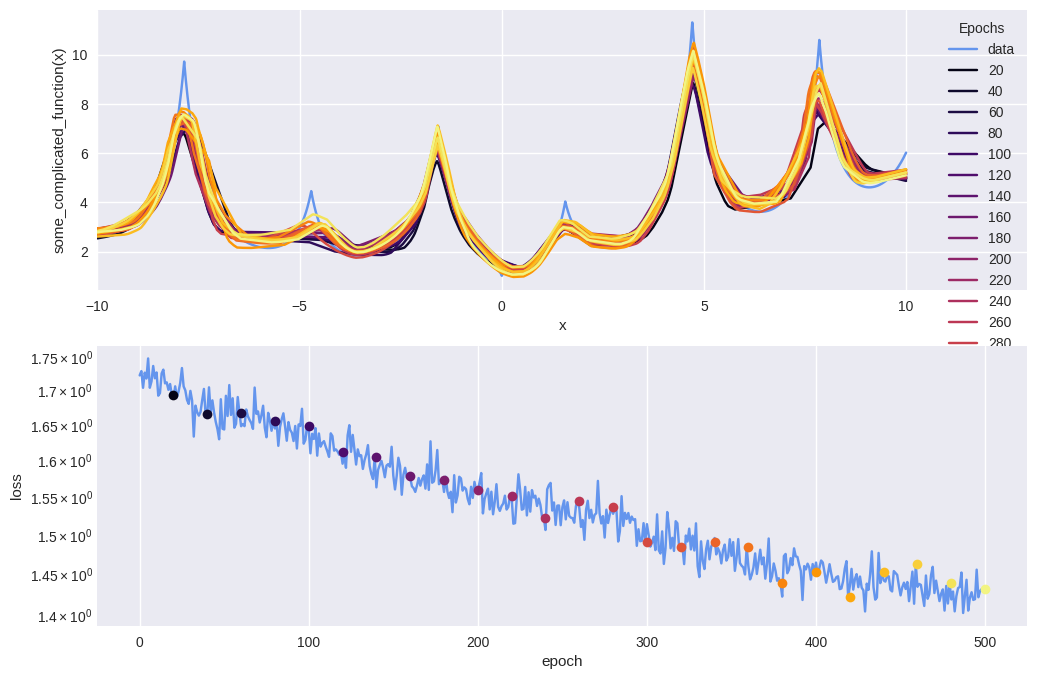

In [17]:
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12, 8))

ax1.plot(xtest, ytest, color="#6495ED", label="data")
saved_epochs = range(save_period, epochs + 1, save_period)

colors = [
    plt.cm.inferno((i + 1) / float(len(saved_epochs) + 1))
    for i in range(len(saved_epochs))
]

for i, epoch in enumerate(saved_epochs):
    model.load_weights("weights-{epoch:02d}.weights.h5".format(epoch=epoch))
    ypredict = model.predict(xtest).squeeze()
    ax1.plot(xtest.squeeze(), ypredict, color=colors[i], label=epoch)
    ax2.plot(
        epoch,
        results.history["loss"][epoch - 1],
        color=colors[i],
        marker="o",
        zorder=10,
    )

ax1.set(xlabel="x", ylabel="some_complicated_function(x)", xlim=(-10, 13), title="")
ax1.grid(True)
ax1.legend(loc="upper right", title="Epochs")

ax2.plot(results.history["loss"], color="#6495ED")
ax2.set(xlabel="epoch", ylabel="loss")
ax2.grid(True)
ax2.semilogy()

plt.show()

In [18]:
ax1.set(
    xlabel="x",
    ylabel="some_complicated_function(x)",
    xlim=(-10, 13),
    title="Neural Network Regression"
)

[Text(0.5, 360.00000000000006, 'x'),
 Text(66.7433935546875, 0.5, 'some_complicated_function(x)'),
 (-10.0, 13.0),
 Text(0.5, 1.0, 'Neural Network Regression')]

###Observation 1

The neural network successfully learned the complicated nonlinear function after sufficient epochs.

###Observation 2

The loss decreased steadily during training, showing that the optimizer improved the prediction accuracy.

###Observation 3

ReLU activation with multiple hidden layers produced smoother predictions and better interpolation.

###Observation 4

L2 regularization and dropout helped reduce overfitting and stabilized the training.